In [ ]:
!pip install keras tensorflow

In [ ]:
!pip install --upgrade tensorflow keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.0 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: pip's dependency resolver

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import text_dataset_from_directory # Updated import
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
import arabic_reshaper
from bidi.algorithm import get_display
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

# Download necessary NLTK data
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **Dataset Analysis**


In [ ]:
# Load the dataset
df = pd.read_csv('merged_cleaned.csv')
df.head()

,Id,date,platform,title,News content,Label
0,1,2023-01-11 00:00:00,Aljazeera,الضفة الغربية.. الاحتلال يهدم 17 منزلا تاريخيا...,هدمت قوات الاحتلال الإسرائيلي -اليوم الأربعاء-...,real
1,2,2023-01-11 00:00:00,Aljazeera,مظاهرات بمدن أوروبية تضامنا مع غزة وحشود أمام ...,خرجت مظاهرات في عدد من المدن الأوروبية مساء ال...,real
2,3,2023-01-11 00:00:00,Aljazeera,شهداء في جنين وطولكرم وإضراب عام بالضفة الغربي...,استشهد 4 فلسطينيين واعتقل عشرات آخرون -اليوم ا...,real
3,4,2023-02-11 00:00:00,Aljazeera,أبو عبيدة: خسائر العدو أكبر بكثير مما يعلن وسن...,أكد الناطق باسمكتائب الشهيد عز الدين القسام-ال...,real
4,5,2023-03-11 00:00:00,Aljazeera,9 شهداء بالضفة والاحتلال يشن حملة اعتقالات,استشهد 9 فلسطينيين في مواجهات اندلعت مع قوات ا...,real


In [ ]:
# Print the number of rows and columns
print(f"Number of rows (data entries): {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows (data entries): 5352
Number of columns: 6


In [ ]:
# Print the distribution of labels (real and fake)
label_counts = df['Label'].value_counts()
print("\nLabel distribution:")
print(f"Real: {label_counts.get('real', 0)} articles")
print(f"Fake: {label_counts.get('fake', 0)} articles")


Label distribution:
Real: 3913 articles
Fake: 1439 articles


In [ ]:
real = 3913
fake = 1439
total = real + fake

real_percent = (real / total) * 100
fake_percent = (fake / total) * 100

print(f"Real: {real_percent:.2f}%")
print(f"Fake: {fake_percent:.2f}%")

Real: 73.11%
Fake: 26.89%


# **Data preprocessing**


In [ ]:
# Data preprocessing
def clean_arabic_text(text):
    # Remove diacritics
    text = re.sub(r'[\u064B-\u065F]', '', text)
    # Normalize Alef
    text = text.replace('أ', 'ا').replace('إ', 'ا').replace('آ', 'ا')
    # Normalize Teh Marbuta
    text = text.replace('ة', 'ه')
    # Normalize Yeh
    text = text.replace('ى', 'ي')
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# Arabic stopwords and stemming
stop_words = set(stopwords.words('arabic'))
stemmer = ISRIStemmer()

def preprocess_text(text):
    text = clean_arabic_text(text)
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing
df['processed_text'] = df['News content'].apply(preprocess_text)

# **Model Selection and Implementation**


In [ ]:
# Split data
X = df['processed_text']
y = df['Label'].map({'real': 1, 'fake': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# **Model 1**

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

# **Model 2**

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

# **Model 3**

In [ ]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

## **Evaluation**


Logistic Regression Evaluation:
Accuracy: 0.8898225957049486
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.78       304
           1       0.89      0.96      0.93       767

    accuracy                           0.89      1071
   macro avg       0.89      0.83      0.86      1071
weighted avg       0.89      0.89      0.89      1071



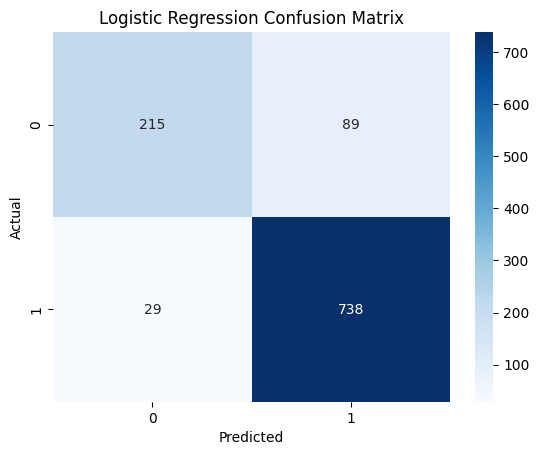


Random Forest Evaluation:
Accuracy: 0.8879551820728291
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       304
           1       0.89      0.96      0.92       767

    accuracy                           0.89      1071
   macro avg       0.88      0.83      0.85      1071
weighted avg       0.89      0.89      0.88      1071



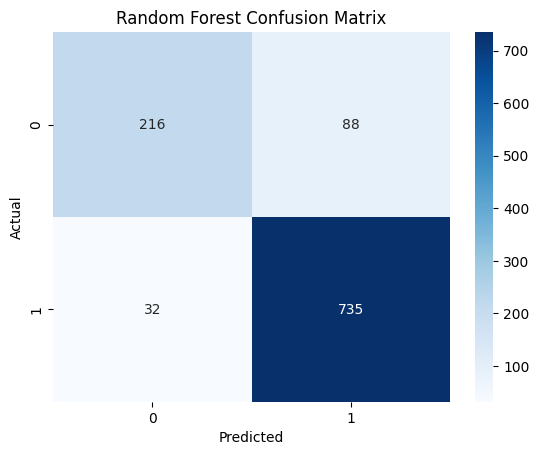


SVM Evaluation:
Accuracy: 0.9028944911297853
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       304
           1       0.92      0.95      0.93       767

    accuracy                           0.90      1071
   macro avg       0.89      0.87      0.88      1071
weighted avg       0.90      0.90      0.90      1071



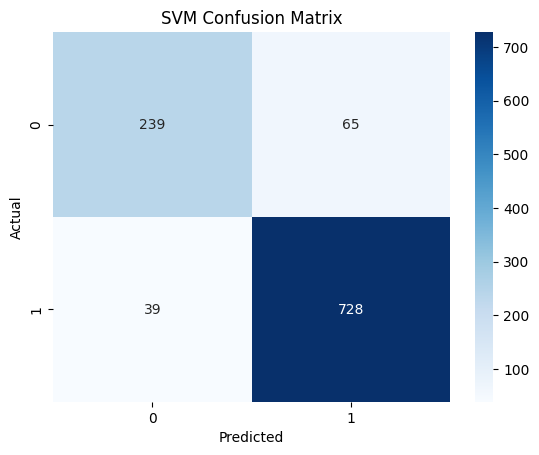

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(y_test, lr_pred, "Logistic Regression")
evaluate_model(y_test, rf_pred, "Random Forest")
evaluate_model(y_test, svm_pred, "SVM")


# **Model Comparison**

| Model                | Accuracy | Precision (0/1) | Recall (0/1) | F1-Score (0/1) | Remarks |
|---------------------|----------|------------------|---------------|----------------|---------|
| **SVM**                 | 0.9029   | 0.86 / 0.92       | 0.79 / 0.95    | 0.82 / 0.93     | Best overall performance; excellent at detecting both classes |
| **Logistic Regression** | 0.8898   | 0.88 / 0.89       | 0.71 / 0.96    | 0.78 / 0.93     | Balanced and effective, slightly behind SVM |
| **Random Forest**       | 0.8880   | 0.87 / 0.89       | 0.71 / 0.96    | 0.78 / 0.92     | Similar to logistic regression, with slightly lower performance |

**Conclusion**:  
The **SVM model** outperformed all others with the highest accuracy (90.3%) and well-balanced precision and recall for both classes. It is particularly strong at identifying real news (class 1) and improves over both Logistic Regression and Random Forest. Therefore, **SVM** is the most suitable choice for this task, assuming training time and resource usage are acceptable.
